# Boosting Models

Runs Optuna-tuned XGBoost, LightGBM, and CatBoost on the full 7.7M dataset.

Each model is tuned with 75 Optuna trials using a minority-weighted F1 objective
(C1=0.35, C2=0.10, C3=0.20, C4=0.35), then evaluated on the test set with and
without per-class threshold tuning.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import config

X_train = np.load(os.path.join(config.OUTPUTS_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(config.OUTPUTS_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(config.OUTPUTS_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(config.OUTPUTS_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(config.OUTPUTS_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(config.OUTPUTS_DIR, 'y_test.npy'))

from preprocessing.pipeline import PreprocessingPipeline
pipeline     = PreprocessingPipeline.load()
feature_cols = pipeline.feature_cols

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Features: {feature_cols}')

Train: (5159638, 20), Val: (1119891, 20), Test: (1120369, 20)
Features: ['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Weather_Condition', 'Amenity', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Civil_Twilight', 'Duration_Seconds', 'Cluster']


## Apply SMOTE to Training Data

In [2]:
from models.xgboost_model import apply_smote

print('Applying original SMOTE (C2 downsampled to 500k, then auto oversample minorities)...')
X_train_sm, y_train_sm = apply_smote(X_train, y_train)
print(f'Post-SMOTE training shape: {X_train_sm.shape}')

Applying original SMOTE (C2 downsampled to 500k, then auto oversample minorities)...
  Class counts before SMOTE: {1: 44265, 2: 4105699, 3: 880104, 4: 129570}
  Downsampling to: {2: 500000, 3: 500000}...
  After undersampling: {1: 44265, 2: 500000, 3: 500000, 4: 129570}
  Applying SMOTE (sampling_strategy='auto')...
  Post-SMOTE counts: {1: 500000, 2: 500000, 3: 500000, 4: 500000}
Post-SMOTE training shape: (2000000, 20)


## Optuna-Tuned XGBoost

In [3]:
from models.xgboost_model import train_xgboost_optuna, tune_thresholds
from evaluation.metrics import evaluate_model

all_results = {}

print('=' * 60)
print('XGBoost Optuna tuning (SMOTE-balanced data, 75 trials)...')
print('=' * 60)
xgb_model, xgb_params, xgb_val_f1 = train_xgboost_optuna(
    X_train_sm, y_train_sm, X_val, y_val,
    class_imbalance_strategy='none',
    n_trials=config.OPTUNA_N_TRIALS,
)
all_results['XGBoost_Optuna'] = evaluate_model(
    xgb_model, X_test, y_test, 'XGBoost Optuna'
)

XGBoost Optuna tuning (SMOTE-balanced data, 75 trials)...


  0%|          | 0/75 [00:00<?, ?it/s]


Best weighted-minority score: 0.4143
Best params: {'n_estimators': 1397, 'max_depth': 12, 'learning_rate': 0.11868362184265319, 'subsample': 0.8616447418790999, 'colsample_bytree': 0.6407217756211634, 'colsample_bylevel': 0.6111203024857463, 'min_child_weight': 14, 'gamma': 0.1385997480465285, 'reg_alpha': 0.011060982914845792, 'reg_lambda': 8.416757382151869e-07, 'max_delta_step': 3}
Best iteration: 1297
Final model val macro_F1: 0.5022
Model saved to e:\Projects\Accident Severity Prediction\outputs\models\xgboost_best.pkl

=== XGBoost Optuna ===
  Accuracy:    0.7230
  Macro F1:    0.5021
  Weighted F1: 0.7533
  F1 per class: C1=0.3146  C2=0.8104  C3=0.5741  C4=0.3094


In [4]:
xgb_thresholds = tune_thresholds(xgb_model, X_val, y_val)
all_results['XGBoost_Optuna+Thresholds'] = evaluate_model(
    xgb_model, X_test, y_test, 'XGBoost Optuna+Thresholds',
    thresholds=xgb_thresholds,
)

  Best thresholds: C1=0.50, C2=0.50, C3=0.86, C4=0.50  macro_F1=0.5066

=== XGBoost Optuna+Thresholds ===
  Accuracy:    0.7503
  Macro F1:    0.5062
  Weighted F1: 0.7771
  F1 per class: C1=0.2976  C2=0.8379  C3=0.5874  C4=0.3019


## Optuna-Tuned LightGBM

In [5]:
from models.lightgbm_model import train_lightgbm_optuna

print('=' * 60)
print('LightGBM Optuna tuning (SMOTE-balanced data, 75 trials)...')
print('=' * 60)
lgb_model, lgb_params, lgb_val_f1 = train_lightgbm_optuna(
    X_train_sm, y_train_sm, X_val, y_val,
    n_trials=config.OPTUNA_N_TRIALS,
)
all_results['LightGBM_Optuna'] = evaluate_model(
    lgb_model, X_test, y_test, 'LightGBM Optuna'
)

lgb_thresholds = tune_thresholds(lgb_model, X_val, y_val)
all_results['LightGBM_Optuna+Thresholds'] = evaluate_model(
    lgb_model, X_test, y_test, 'LightGBM Optuna+Thresholds',
    thresholds=lgb_thresholds,
)

LightGBM Optuna tuning (SMOTE-balanced data, 75 trials)...


  0%|          | 0/75 [00:00<?, ?it/s]


LightGBM best weighted-minority score: 0.4262
Best params: {'boosting_type': 'gbdt', 'n_estimators': 1767, 'num_leaves': 221, 'max_depth': 10, 'learning_rate': 0.11631138908896639, 'min_child_samples': 162, 'subsample': 0.8979905614908295, 'colsample_bytree': 0.9671786066276329, 'reg_alpha': 0.00032138497693991544, 'reg_lambda': 1.336129404351858, 'min_split_gain': 0.15434398376164507, 'extra_trees': False}
Best iteration (early stopping probe): 855
Final model val macro_F1: 0.5018
Model saved to e:\Projects\Accident Severity Prediction\outputs\models\lightgbm_best.pkl

=== LightGBM Optuna ===
  Accuracy:    0.7214
  Macro F1:    0.5018
  Weighted F1: 0.7515
  F1 per class: C1=0.3254  C2=0.8097  C3=0.5673  C4=0.3046
  Best thresholds: C1=0.50, C2=0.50, C3=0.82, C4=0.50  macro_F1=0.5074

=== LightGBM Optuna+Thresholds ===
  Accuracy:    0.7496
  Macro F1:    0.5070
  Weighted F1: 0.7759
  F1 per class: C1=0.3115  C2=0.8378  C3=0.5813  C4=0.2974


## Optuna-Tuned CatBoost

In [6]:
from models.catboost_model import train_catboost_optuna

print('=' * 60)
print('CatBoost Optuna tuning (SMOTE-balanced data, 75 trials)...')
print('=' * 60)
cat_model, cat_params, cat_val_f1 = train_catboost_optuna(
    X_train_sm, y_train_sm, X_val, y_val,
    n_trials=config.OPTUNA_N_TRIALS,
)
all_results['CatBoost_Optuna'] = evaluate_model(
    cat_model, X_test, y_test, 'CatBoost Optuna'
)

class CatWrapper:
    def __init__(self, m): self.m = m
    def predict_proba(self, X): return self.m.predict_proba(X)

cat_thresholds = tune_thresholds(CatWrapper(cat_model), X_val, y_val)
all_results['CatBoost_Optuna+Thresholds'] = evaluate_model(
    cat_model, X_test, y_test, 'CatBoost Optuna+Thresholds',
    thresholds=cat_thresholds,
)

CatBoost Optuna tuning (SMOTE-balanced data, 75 trials)...


  0%|          | 0/75 [00:00<?, ?it/s]


CatBoost best weighted-minority score: 0.3995
Best params: {'bootstrap_type': 'Bernoulli', 'iterations': 1833, 'learning_rate': 0.2533480812165291, 'depth': 10, 'l2_leaf_reg': 1.551261817043434, 'border_count': 220, 'random_strength': 1.5682690577773324, 'min_data_in_leaf': 50, 'subsample': 0.8645703808095165}
Best iteration: 1832
Final model val macro_F1: 0.4899
Model saved to e:\Projects\Accident Severity Prediction\outputs\models\catboost_best.pkl

=== CatBoost Optuna ===
  Accuracy:    0.7169
  Macro F1:    0.4908
  Weighted F1: 0.7479
  F1 per class: C1=0.3018  C2=0.8063  C3=0.5660  C4=0.2889
  Best thresholds: C1=0.50, C2=0.50, C3=0.88, C4=0.50  macro_F1=0.4958

=== CatBoost Optuna+Thresholds ===
  Accuracy:    0.7466
  Macro F1:    0.4954
  Weighted F1: 0.7738
  F1 per class: C1=0.2822  C2=0.8365  C3=0.5787  C4=0.2840


## Final Comparison Table

In [7]:
from evaluation.metrics import print_model_comparison_table

all_results['Original Report (XGBoost 7.7M)'] = {
    'accuracy': 0.7716, 'macro_f1': 0.55, 'weighted_f1': 0.79,
    'f1_class_1': 0.39, 'f1_class_2': 0.85,
    'f1_class_3': 0.60, 'f1_class_4': 0.35,
}

df_results = print_model_comparison_table(all_results)
df_results


Model                             Accuracy  MacroF1   F1-C1   F1-C2   F1-C3   F1-C4
----------------------------------------------------------------------------------
  XGBoost_Optuna                    0.7230   0.5021  0.3146  0.8104  0.5741  0.3094
  XGBoost_Optuna+Thresholds         0.7503   0.5062  0.2976  0.8379  0.5874  0.3019
  LightGBM_Optuna                   0.7214   0.5018  0.3254  0.8097  0.5673  0.3046
  LightGBM_Optuna+Thresholds        0.7496   0.5070  0.3115  0.8378  0.5813  0.2974
  CatBoost_Optuna                   0.7169   0.4908  0.3018  0.8063  0.5660  0.2889
  CatBoost_Optuna+Thresholds        0.7466   0.4954  0.2822  0.8365  0.5787  0.2840
  Original Report (XGBoost 7.7M)    0.7716   0.5500  0.3900  0.8500  0.6000  0.3500
----------------------------------------------------------------------------------

Results saved to e:\Projects\Accident Severity Prediction\outputs\results\all_model_results.csv


,accuracy,macro_f1,weighted_f1,f1_class_1,f1_class_2,f1_class_3,f1_class_4
Model,,,,,,,
XGBoost_Optuna,0.7230,0.5021,0.7533,0.3146,0.8104,0.5741,0.3094
XGBoost_Optuna+Thresholds,0.7503,0.5062,0.7771,0.2976,0.8379,0.5874,0.3019
LightGBM_Optuna,0.7214,0.5018,0.7515,0.3254,0.8097,0.5673,0.3046
LightGBM_Optuna+Thresholds,0.7496,0.5070,0.7759,0.3115,0.8378,0.5813,0.2974
CatBoost_Optuna,0.7169,0.4908,0.7479,0.3018,0.8063,0.5660,0.2889
CatBoost_Optuna+Thresholds,0.7466,0.4954,0.7738,0.2822,0.8365,0.5787,0.2840
Original Report (XGBoost 7.7M),0.7716,0.5500,0.7900,0.3900,0.8500,0.6000,0.3500


In [8]:
boosting_results = {k: v for k, v in all_results.items() if 'Original Report' not in k}
best_name  = max(boosting_results, key=lambda s: boosting_results[s]['macro_f1'])
best_macro = boosting_results[best_name]['macro_f1']
c1_f1      = boosting_results[best_name]['f1_class_1']
c4_f1      = boosting_results[best_name]['f1_class_4']

print(f'Best model: {best_name}')
print(f'  Macro F1:  {best_macro:.4f}  (original report: 0.55)')
print(f'  F1-C1:     {c1_f1:.4f}    (original report: 0.39)')
print(f'  F1-C4:     {c4_f1:.4f}    (original report: 0.35)')

Best model: LightGBM_Optuna+Thresholds
  Macro F1:  0.5070  (original report: 0.55)
  F1-C1:     0.3115    (original report: 0.39)
  F1-C4:     0.2974    (original report: 0.35)


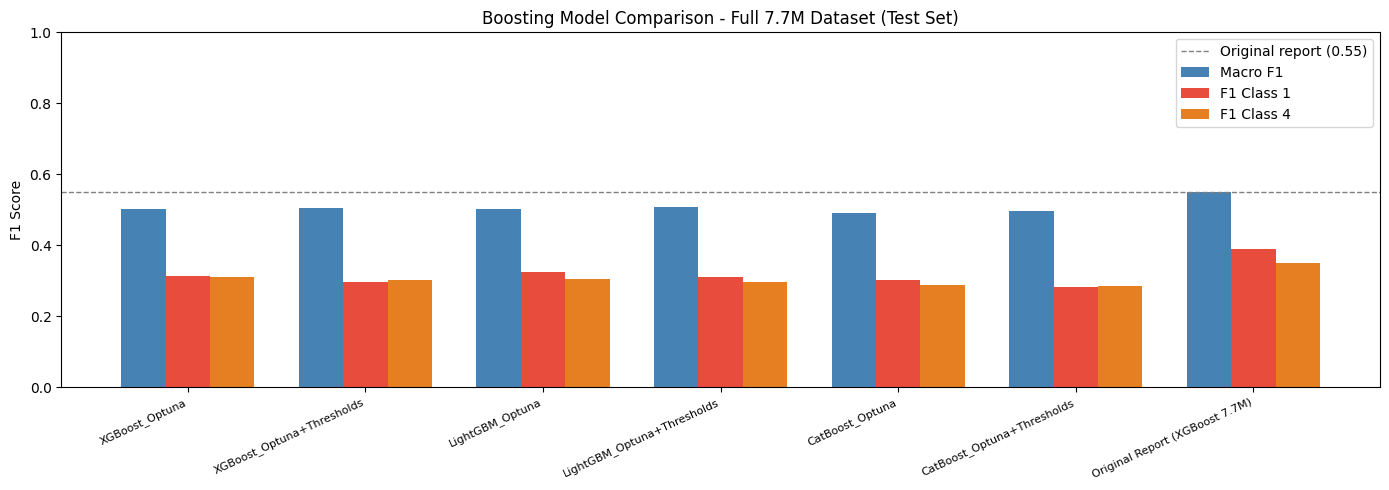

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
keys = list(all_results.keys())
x = np.arange(len(keys))
w = 0.25
ax.bar(x - w, [all_results[k]['macro_f1']   for k in keys], w, label='Macro F1',   color='steelblue')
ax.bar(x,     [all_results[k]['f1_class_1'] for k in keys], w, label='F1 Class 1', color='#e74c3c')
ax.bar(x + w, [all_results[k]['f1_class_4'] for k in keys], w, label='F1 Class 4', color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels(keys, rotation=25, ha='right', fontsize=8)
ax.axhline(0.55, color='gray', linestyle='--', linewidth=1, label='Original report (0.55)')
ax.set_ylabel('F1 Score')
ax.set_title('Boosting Model Comparison - Full 7.7M Dataset (Test Set)')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(config.PLOTS_DIR, 'phase3_comparison.png'), dpi=120)
plt.show()

In [10]:
import json

boosting_only = {k: v for k, v in all_results.items() if 'Original Report' not in k}
best_name = max(boosting_only, key=lambda k: boosting_only[k]['macro_f1'])

if 'XGBoost' in best_name:
    model_type          = 'XGBoost'
    best_model_params   = xgb_params
    best_thresholds_arr = xgb_thresholds.tolist()
elif 'LightGBM' in best_name:
    model_type          = 'LightGBM'
    best_model_params   = lgb_params
    best_thresholds_arr = lgb_thresholds.tolist()
else:
    model_type          = 'CatBoost'
    best_model_params   = cat_params
    best_thresholds_arr = cat_thresholds.tolist()

best_run = {
    'model':        model_type,
    'params':       best_model_params,
    'val_macro_f1': boosting_only[best_name]['macro_f1'],
    'thresholds':   best_thresholds_arr,
}
out_path = os.path.join(config.RESULTS_DIR, 'best_params.json')
with open(out_path, 'w') as f:
    json.dump(best_run, f, indent=2)

print(f'Best model : {model_type} ({best_name})')
print(f'Macro F1   : {best_run["val_macro_f1"]:.4f}')
print(f'Saved to   : {out_path}')

Best model : LightGBM (LightGBM_Optuna+Thresholds)
Macro F1   : 0.5070
Saved to   : e:\Projects\Accident Severity Prediction\outputs\results\best_params.json
